# CS3807 – Deep Learning Laboratory
# Experiment 4: Comparative Study of Deep CNN Architectures Using Transfer Learning

**Dataset:** CIFAR-10 (loaded from Kaggle: `pankrzysiu/cifar10-python`)
**Random seed:** 109 (fixed throughout for reproducibility)


## 1. Setup: Packages, Seeds, Plot Styling

Sets every random seed to **109**, and configures matplotlib so all saved plots use Times New Roman, font size 13–15, bold axis labels — as required for the report figures.



In [ ]:

# ---- Install & imports ----
!pip install -q kaggle scikit-learn

# msttcorefonts requires accepting Microsoft's EULA via debconf -- without this line,
# `apt-get install -y` silently fails to install it (no error shown), and matplotlib
# falls back to a default sans-serif font with no warning. Pre-seeding the answer fixes that.
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!apt-get install -y -qq ttf-mscorefonts-installer
!rm -rf ~/.cache/matplotlib

import os, sys, time, random, pickle, zipfile, shutil, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, applications
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

# ---- Reproducibility: seed = 109 ----
SEED = 109
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Register Times New Roman directly with matplotlib (no runtime restart needed) ----
found_fonts = subprocess.run(['find', '/usr/share/fonts', '-iname', '*times*'],
                              capture_output=True, text=True).stdout.strip().split('\n')
found_fonts = [p for p in found_fonts if p.strip()]
print("Times New Roman font files found:", found_fonts)
for fpath in found_fonts:
    try:
        fm.fontManager.addfont(fpath)
    except Exception as e:
        print(f"Could not register {fpath}: {e}")

# ---- Plot styling: Times New Roman, 13-15pt, bold axes ----
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13

# ---- Verify the font actually resolved (don't just hope) ----
resolved_path = fm.findfont(fm.FontProperties(family='Times New Roman'))
print("matplotlib will use font file:", resolved_path)
if 'times' not in resolved_path.lower() and 'Times' not in resolved_path:
    print("WARNING: Times New Roman did NOT resolve correctly -- plots will NOT use it. "
          "If you see this warning, tell me before generating any plots.")

PLOTS_DIR = '/content/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

def save_plot(fig, name):
    """Save a figure into PLOTS_DIR at report quality."""
    path = os.path.join(PLOTS_DIR, name)
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f"Saved: {path}")

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


Times New Roman font files found: ['/usr/share/fonts/truetype/msttcorefonts/timesi.ttf', '/usr/share/fonts/truetype/msttcorefonts/timesbi.ttf', '/usr/share/fonts/truetype/msttcorefonts/times.ttf', '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf', '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold_Italic.ttf', '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Italic.ttf', '/usr/share/fonts/truetype/msttcorefonts/timesbd.ttf', '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf']
matplotlib will use font file: /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf
TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Kaggle Authentication


In [ ]:

from google.colab import files

print("Upload your kaggle.json file:")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle credentials configured.")


Upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
Kaggle credentials configured.


## 3. Download CIFAR-10 (Kaggle: `pankrzysiu/cifar10-python`)

This dataset is the original Toronto CIFAR-10 **python pickle** distribution (`data_batch_1..5`, `test_batch`, `batches.meta`). The cell below downloads it and then **prints exactly what it finds** so we catch it immediately if Kaggle's packaging has changed, instead of failing silently later.

In [ ]:

!kaggle datasets download -d pankrzysiu/cifar10-python -p /content/data --unzip

DATA_ROOT = '/content/data'
print("Top-level contents of /content/data:")
for root, dirs, fnames in os.walk(DATA_ROOT):
    depth = root.replace(DATA_ROOT, '').count(os.sep)
    if depth > 2:
        continue
    print('  ' * depth + os.path.basename(root) + '/')
    for f in fnames[:10]:
        print('  ' * (depth + 1) + f)


Dataset URL: https://www.kaggle.com/datasets/pankrzysiu/cifar10-python
License(s): other
100% 325M/325M [00:16<00:00, 21.1MB/s]

Top-level contents of /content/data:
data/
  cifar-10-python.tar.gz
  cifar-10-batches-py/
    data_batch_5
    data_batch_3
    data_batch_2
    batches.meta
    test_batch
    data_batch_1
    data_batch_4
    readme.html


## 4. Load CIFAR-10 into NumPy Arrays


In [ ]:
def find_batches_dir(root):
    for r, dirs, fnames in os.walk(root):
        if any(f.startswith('data_batch_') for f in fnames):
            return r
    raise FileNotFoundError(
        "Could not find 'data_batch_*' files anywhere under the download. "
        "The dataset's structure doesn't match the expected pickle format — "
        "check the directory listing printed above and adjust the loader."
    )

BATCHES_DIR = find_batches_dir(DATA_ROOT)
print("Using batches directory:", BATCHES_DIR)

def unpickle(file):
    with open(file, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

def load_cifar10(batches_dir):
    x_train, y_train = [], []
    for i in range(1, 6):
        batch = unpickle(os.path.join(batches_dir, f'data_batch_{i}'))
        x_train.append(batch[b'data'])
        y_train.extend(batch[b'labels'])
    x_train = np.concatenate(x_train).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_train = np.array(y_train)

    test_batch = unpickle(os.path.join(batches_dir, 'test_batch'))
    x_test = test_batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_test = np.array(test_batch[b'labels'])

    meta = unpickle(os.path.join(batches_dir, 'batches.meta'))
    label_names = [l.decode('utf-8') for l in meta[b'label_names']]

    return x_train, y_train, x_test, y_test, label_names

x_train, y_train, x_test, y_test, CLASS_NAMES = load_cifar10(BATCHES_DIR)

# Normalize to [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Keep integer-label copies for confusion_matrix / classification_report / plot titles
y_train_int = y_train.copy()
y_test_int = y_test.copy()

# One-hot encode for training — manual specifies Categorical Cross Entropy, which
# requires one-hot targets (Sparse Categorical Cross Entropy would take integer labels)
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print("Train shape:", x_train.shape, "| Test shape:", x_test.shape)
print("Train labels shape (one-hot):", y_train.shape)
print("Classes:", CLASS_NAMES)

Using batches directory: /content/data/cifar-10-batches-py
Train shape: (50000, 32, 32, 3) | Test shape: (10000, 32, 32, 3)
Train labels shape (one-hot): (50000, 10)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 5. Sample Images & Dataset Dimensions (Plot 1)

Saved: /content/plots/01_sample_images.png


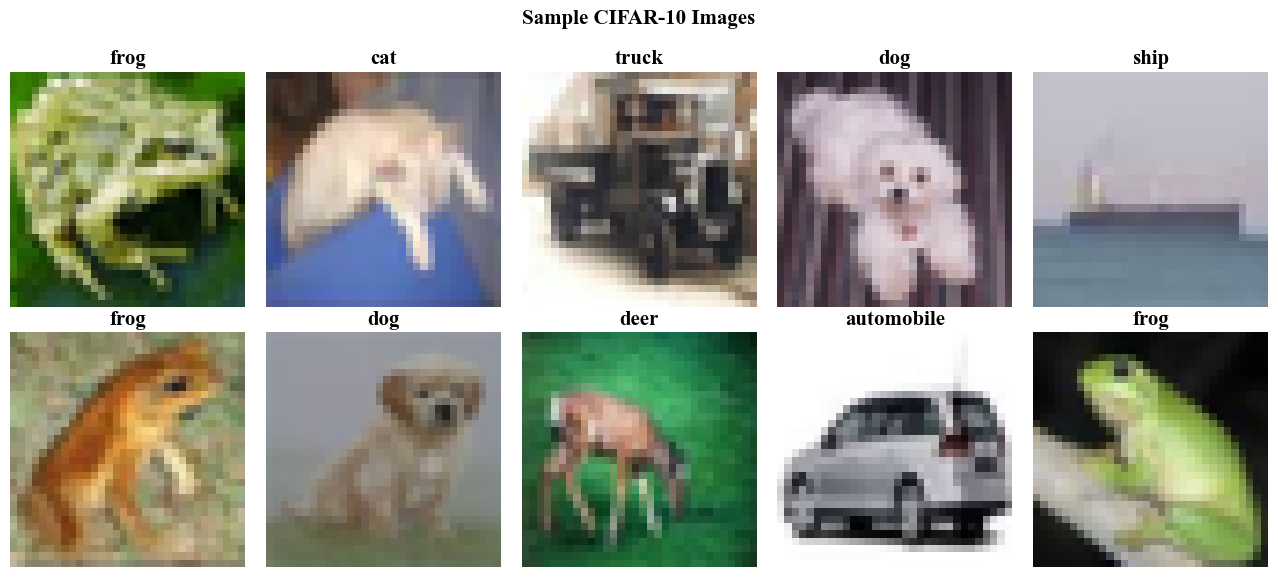

Training set: 50000 images, shape (32, 32, 3)
Testing set:  10000 images, shape (32, 32, 3)


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(x_train), 10, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(x_train[idx])
    ax.set_title(CLASS_NAMES[y_train_int[idx]], fontweight='bold')
    ax.axis('off')
fig.suptitle('Sample CIFAR-10 Images', fontweight='bold', fontsize=15)
plt.tight_layout()
save_plot(fig, '01_sample_images.png')
plt.show()

print(f"Training set: {x_train.shape[0]} images, shape {x_train.shape[1:]}")
print(f"Testing set:  {x_test.shape[0]} images, shape {x_test.shape[1:]}")

## 6. A Note on Input Size and Preprocessing

MobileNetV2 / VGG16 / ResNet50 were pretrained on 224×224 ImageNet images. CIFAR-10 is 32×32. Feeding 32×32 directly still *runs* (these architectures accept inputs ≥32×32 due to global average pooling at the end), but the feature maps collapse to almost nothing by the final conv block, wasting most of the pretrained representation.

**Trade-off used here:** a `Resizing` layer inside the model upsamples to **96×96** on the GPU per-batch (not pre-computed and stored — that would need ~5GB+ of RAM for the full training set). 96×96 is a middle ground: meaningfully better feature reuse than raw 32×32, without the training time of full 224×224.

**Preprocessing scale:** `x_train`/`x_test` are normalized to `[0,1]` per Task 1. Keras's `preprocess_input` functions (`mobilenet_v2.preprocess_input`, etc.) expect **raw 0-255** pixel values — that's their documented contract, since that's the scale the ImageNet weights were trained on. The model below multiplies by 255 right before calling `preprocess_fn`, so the backbone sees the scale it actually expects, while the rest of the notebook keeps `[0,1]` data as the manual specifies.

In [ ]:

IMG_SIZE = 96  # upsample target for all transfer-learning backbones
NUM_CLASSES = 10

def build_transfer_model(base_model_fn, preprocess_fn, dense_units=128, trainable_base=False):
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
    # NOTE: x_train/x_test are normalized to [0,1] (Task 1 requirement), but Keras's
    # preprocess_input functions expect raw 0-255 pixel values -- that's their contract.
    # Multiplying by 255 here undoes our [0,1] normalization *just* before the backbone,
    # so the pretrained model gets input on the scale it was actually trained on.
    x = layers.Lambda(lambda t: preprocess_fn(t * 255.0))(x)
    base = base_model_fn(include_top=False, weights='imagenet',
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = trainable_base
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model, base

results = {}  # Model name -> {'params': int, 'accuracy': float, 'train_time_sec': float}
histories = {}  # Model name -> keras History


## 7. Task 2 & 3: MobileNetV2 — Transfer Learning (Frozen Base) + Training

In [ ]:
mobilenet_model, mobilenet_base = build_transfer_model(
    applications.MobileNetV2, applications.mobilenet_v2.preprocess_input,
    dense_units=128, trainable_base=False
)
mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
mobilenet_model.summary()

MOBILENET_PARAMS = mobilenet_model.count_params()
print(f"Total parameters: {MOBILENET_PARAMS:,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Total parameters: 2,423,242


In [ ]:

EPOCHS_PRIMARY = 15
BATCH_SIZE = 32

t0 = time.time()
history_frozen = mobilenet_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS_PRIMARY,
    batch_size=BATCH_SIZE,
    verbose=1
)
frozen_train_time = time.time() - t0
print(f"Frozen-base training time: {frozen_train_time/60:.2f} minutes")
histories['MobileNetV2_frozen'] = history_frozen


Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 21ms/step - accuracy: 0.8282 - loss: 0.4999 - val_accuracy: 0.8502 - val_loss: 0.4310
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8763 - loss: 0.3567 - val_accuracy: 0.8549 - val_loss: 0.4222
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8974 - loss: 0.2951 - val_accuracy: 0.8535 - val_loss: 0.4295
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9167 - loss: 0.2426 - val_accuracy: 0.8514 - val_loss: 0.4471
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9325 - loss: 0.1969 - val_accuracy: 0.8482 - val_loss: 0.4754
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9468 - loss: 0.1593 - val_accuracy: 0.8429 - val_loss: 0.5297
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9531 - loss: 0.1348 - val_accuracy: 0.8387 - val_loss: 0.5873
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9611 - l

## 8. Training/Validation Accuracy & Loss Plots (Plots 2–5)

Saved: /content/plots/02_training_accuracy.png


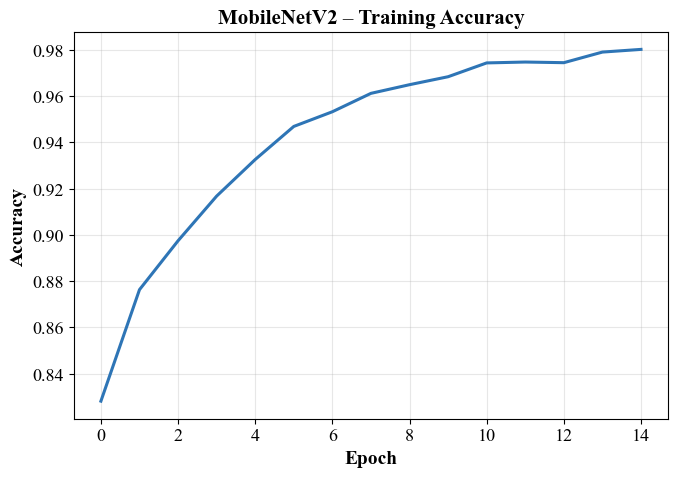

Saved: /content/plots/03_validation_accuracy.png


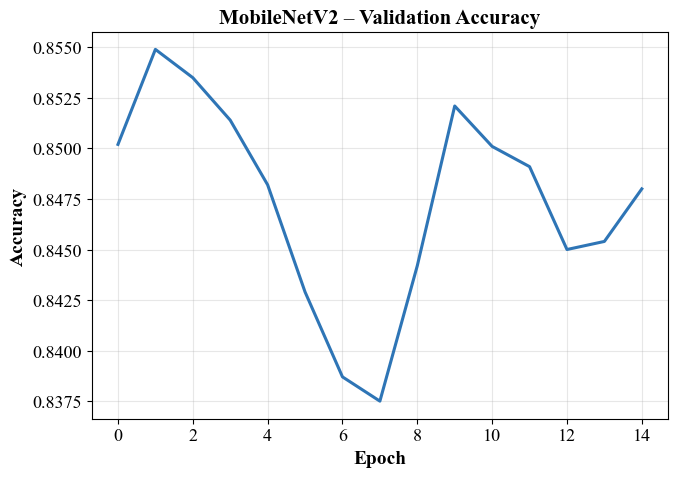

Saved: /content/plots/04_training_loss.png


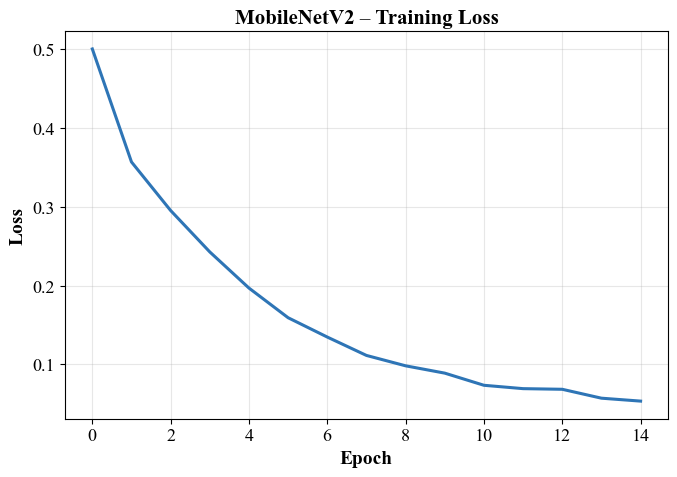

Saved: /content/plots/05_validation_loss.png


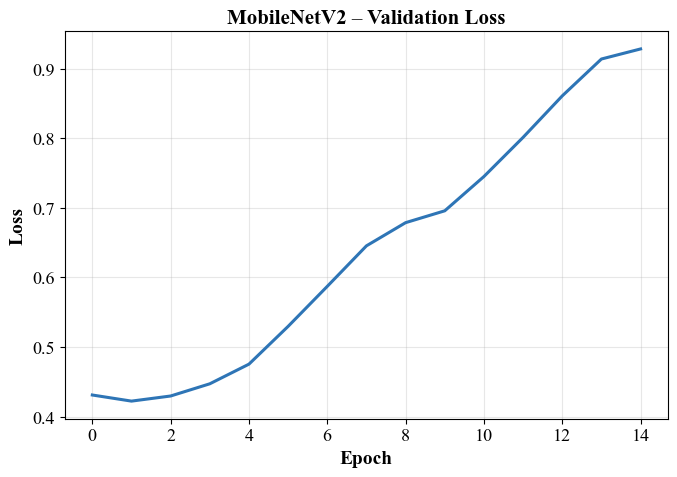

In [ ]:

def plot_single_metric(history, key, title, fname, ylabel):
    """Plots ONE curve only -- keeps Training Accuracy/Validation Accuracy/Training Loss/
    Validation Loss as four genuinely distinct plots, matching the manual's mandatory list
    (items 2-5) rather than one chart duplicated under different titles."""
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(history.history[key], color='#2E75B6', linewidth=2.2)
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    save_plot(fig, fname)
    plt.show()

plot_single_metric(history_frozen, 'accuracy', 'MobileNetV2 – Training Accuracy',
                    '02_training_accuracy.png', 'Accuracy')
plot_single_metric(history_frozen, 'val_accuracy', 'MobileNetV2 – Validation Accuracy',
                    '03_validation_accuracy.png', 'Accuracy')
plot_single_metric(history_frozen, 'loss', 'MobileNetV2 – Training Loss',
                    '04_training_loss.png', 'Loss')
plot_single_metric(history_frozen, 'val_loss', 'MobileNetV2 – Validation Loss',
                    '05_validation_loss.png', 'Loss')


## 9. Task 4: Fine-Tuning MobileNetV2

Unfreezes the last convolutional block and continues training at a lower learning rate.

In [ ]:
mobilenet_base.trainable = True
FINE_TUNE_AT = len(mobilenet_base.layers) - 20
for layer in mobilenet_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

FINE_TUNE_EPOCHS = 8
t0 = time.time()
history_finetune = mobilenet_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=FINE_TUNE_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
finetune_train_time = time.time() - t0
print(f"Fine-tuning time: {finetune_train_time/60:.2f} minutes")
histories['MobileNetV2_finetuned'] = history_finetune

TOTAL_MOBILENET_TIME = frozen_train_time + finetune_train_time

Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 21ms/step - accuracy: 0.8477 - loss: 0.8463 - val_accuracy: 0.8091 - val_loss: 0.7918
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9504 - loss: 0.1469 - val_accuracy: 0.8508 - val_loss: 0.7245
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9768 - loss: 0.0706 - val_accuracy: 0.8456 - val_loss: 0.9444
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9669 - loss: 0.1015 - val_accuracy: 0.8525 - val_loss: 0.8845
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9732 - loss: 0.0813 - val_accuracy: 0.8585 - val_loss: 0.9091
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9800 - loss: 0.0612 - val_accuracy: 0.8518 - val_loss: 0.8857
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9799 - loss: 0.0625 - val_accuracy: 0.8562 - val_loss: 0.9831
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9846 - loss: 0

Saved: /content/plots/06_before_after_finetuning.png


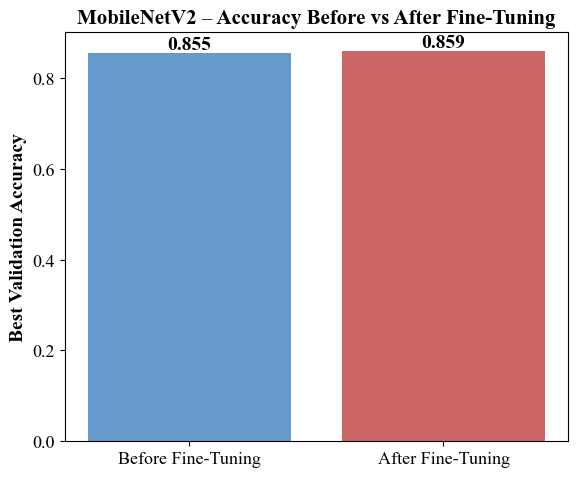

Validation accuracy before fine-tuning: 0.8549
Validation accuracy after fine-tuning:  0.8585


In [ ]:

acc_before = max(history_frozen.history['val_accuracy'])
acc_after = max(history_finetune.history['val_accuracy'])

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Before Fine-Tuning', 'After Fine-Tuning'], [acc_before, acc_after],
              color=['#6699CC', '#CC6666'])
ax.set_ylabel('Best Validation Accuracy', fontweight='bold')
ax.set_title('MobileNetV2 – Accuracy Before vs After Fine-Tuning', fontweight='bold')
for bar, val in zip(bars, [acc_before, acc_after]):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
save_plot(fig, '06_before_after_finetuning.png')
plt.show()

print(f"Validation accuracy before fine-tuning: {acc_before:.4f}")
print(f"Validation accuracy after fine-tuning:  {acc_after:.4f}")


## 10. Task 5: Full Evaluation (MobileNetV2)

In [ ]:
def evaluate_model(model, x_test, y_test_int, class_names, model_name):
    y_prob = model.predict(x_test, batch_size=64, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test_int, y_pred)
    prec = precision_score(y_test_int, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_int, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_int, y_pred, average='weighted', zero_division=0)

    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}\n")
    print(classification_report(y_test_int, y_pred, target_names=class_names))

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'y_pred': y_pred, 'y_prob': y_prob}

mobilenet_eval = evaluate_model(mobilenet_model, x_test, y_test_int, CLASS_NAMES, "MobileNetV2 (fine-tuned)")

results['MobileNetV2'] = {
    'params': MOBILENET_PARAMS,
    'accuracy': mobilenet_eval['accuracy'],
    'train_time_sec': TOTAL_MOBILENET_TIME
}

--- MobileNetV2 (fine-tuned) ---
Accuracy:  0.8510
Precision: 0.8605
Recall:    0.8510
F1-score:  0.8502

              precision    recall  f1-score   support

    airplane       0.96      0.70      0.81      1000
  automobile       0.94      0.91      0.93      1000
        bird       0.73      0.89      0.80      1000
         cat       0.80      0.70      0.74      1000
        deer       0.89      0.75      0.81      1000
         dog       0.76      0.87      0.81      1000
        frog       0.79      0.95      0.86      1000
       horse       0.96      0.86      0.90      1000
        ship       0.91      0.94      0.92      1000
       truck       0.87      0.95      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



Saved: /content/plots/07_confusion_matrix.png


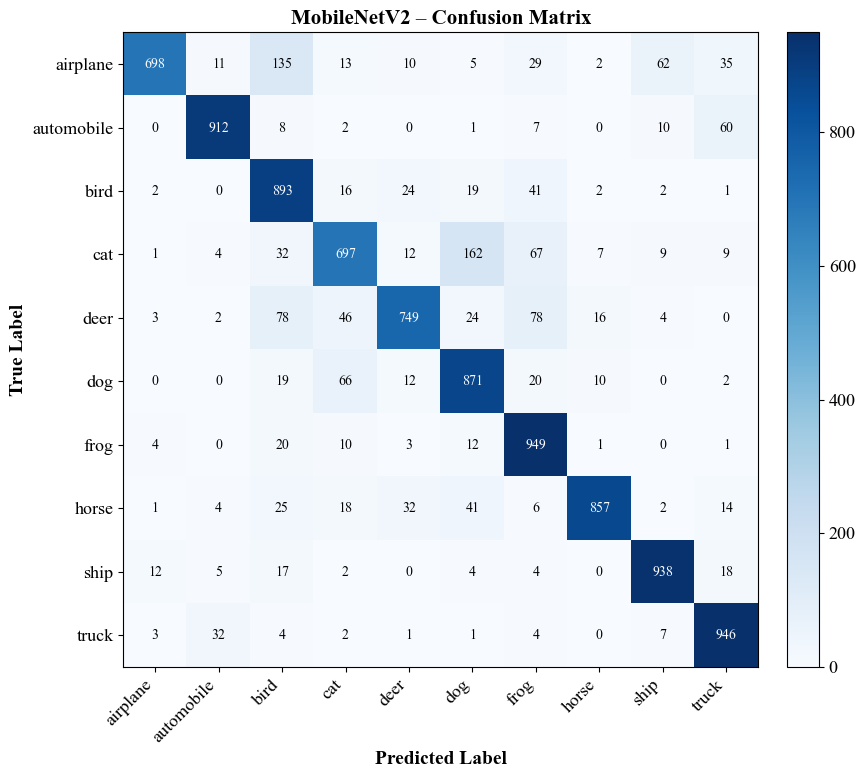

In [ ]:
cm = confusion_matrix(y_test_int, mobilenet_eval['y_pred'])
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
ax.set_title('MobileNetV2 – Confusion Matrix', fontweight='bold')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
save_plot(fig, '07_confusion_matrix.png')
plt.show()

Saved: /content/plots/08_misclassified_images.png


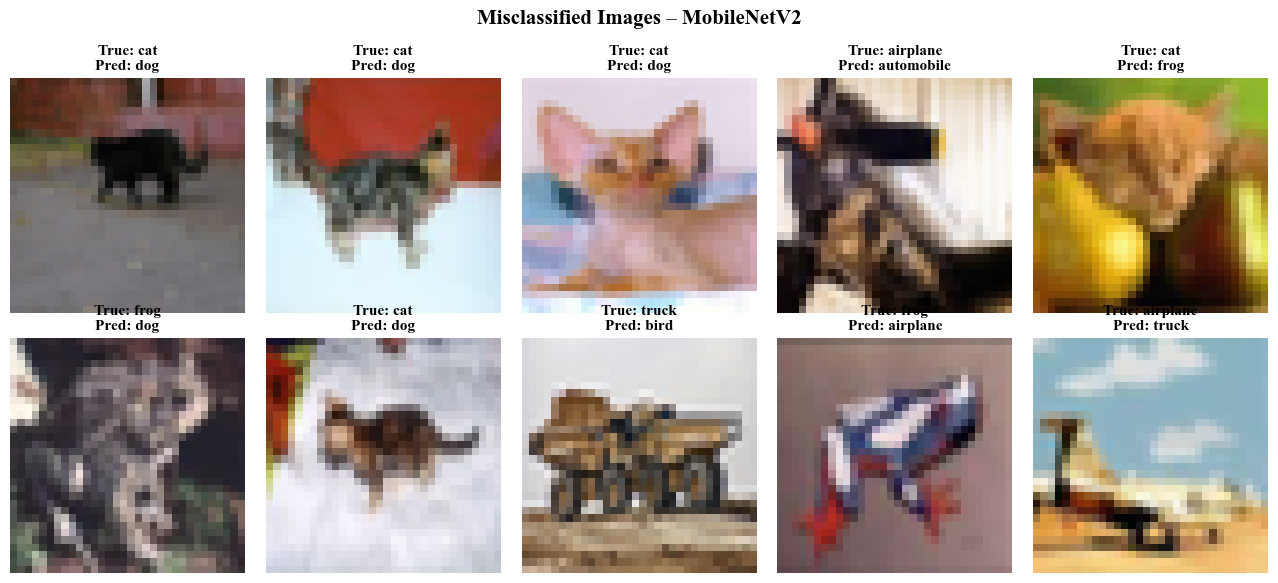

In [ ]:
mis_idx = np.where(mobilenet_eval['y_pred'] != y_test_int)[0]
show_idx = np.random.RandomState(SEED).choice(mis_idx, min(10, len(mis_idx)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, idx in zip(axes.flat, show_idx):
    ax.imshow(x_test[idx])
    ax.set_title(f"True: {CLASS_NAMES[y_test_int[idx]]}\nPred: {CLASS_NAMES[mobilenet_eval['y_pred'][idx]]}",
                 fontsize=11)
    ax.axis('off')
fig.suptitle('Misclassified Images – MobileNetV2', fontweight='bold', fontsize=15)
plt.tight_layout()
save_plot(fig, '08_misclassified_images.png')
plt.show()

**Inference (your own words for the report):**

_[Your observations on the confusion matrix / misclassifications go here.]_

## 11. Section 16: Hyperparameter Study (One-Factor-at-a-Time)

The manual's hyperparameter table has 6 parameters × 2-3 values each — a full grid would be 96 training runs, not realistic on Colab. This cell varies **one parameter at a time** off a fixed baseline (Adam, LR 0.001, batch 32, 128 dense units, frozen base), retraining MobileNetV2 briefly for each.

In [ ]:
BASELINE = dict(lr=0.001, batch_size=32, optimizer='adam', dense_units=128, frozen=True)
HP_EPOCHS = 5  # default epoch count for all variants EXCEPT the Epochs sweep itself

def train_variant(lr, batch_size, optimizer_name, dense_units, frozen, run_name, epochs=HP_EPOCHS):
    model, base = build_transfer_model(
        applications.MobileNetV2, applications.mobilenet_v2.preprocess_input,
        dense_units=dense_units, trainable_base=not frozen
    )
    opt = optimizers.Adam(learning_rate=lr) if optimizer_name == 'adam' else optimizers.SGD(learning_rate=lr, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    hist = model.fit(x_train, y_train, validation_data=(x_test, y_test),
                      epochs=epochs, batch_size=batch_size, verbose=0)
    elapsed = time.time() - t0
    best_val_acc = max(hist.history['val_accuracy'])
    print(f"{run_name}: val_acc={best_val_acc:.4f}, time={elapsed:.1f}s")
    return {'run': run_name, 'val_accuracy': best_val_acc, 'time_sec': elapsed}

hp_results = []

for lr in [0.001, 0.0001]:
    hp_results.append(train_variant(lr, BASELINE['batch_size'], BASELINE['optimizer'],
                                     BASELINE['dense_units'], BASELINE['frozen'], f'LR={lr}'))
for bs in [16, 64]:
    hp_results.append(train_variant(BASELINE['lr'], bs, BASELINE['optimizer'],
                                     BASELINE['dense_units'], BASELINE['frozen'], f'BatchSize={bs}'))
for ep in [10, 20]:
    hp_results.append(train_variant(BASELINE['lr'], BASELINE['batch_size'], BASELINE['optimizer'],
                                     BASELINE['dense_units'], BASELINE['frozen'], f'Epochs={ep}', epochs=ep))
for opt_name in ['sgd']:
    hp_results.append(train_variant(BASELINE['lr'], BASELINE['batch_size'], opt_name,
                                     BASELINE['dense_units'], BASELINE['frozen'], f'Optimizer={opt_name}'))
for du in [256]:
    hp_results.append(train_variant(BASELINE['lr'], BASELINE['batch_size'], BASELINE['optimizer'],
                                     du, BASELINE['frozen'], f'DenseUnits={du}'))
for frozen_flag in [False]:
    hp_results.append(train_variant(BASELINE['lr'], BASELINE['batch_size'], BASELINE['optimizer'],
                                     BASELINE['dense_units'], frozen_flag, 'FrozenLayers=Partial'))

hp_df = pd.DataFrame(hp_results)
hp_df


LR=0.001: val_acc=0.8567, time=105.0s
LR=0.0001: val_acc=0.8606, time=94.0s
BatchSize=16: val_acc=0.8585, time=130.7s
BatchSize=64: val_acc=0.8632, time=77.2s
Epochs=10: val_acc=0.8621, time=169.0s
Epochs=20: val_acc=0.8593, time=321.3s
Optimizer=sgd: val_acc=0.8566, time=93.4s
DenseUnits=256: val_acc=0.8601, time=97.3s
FrozenLayers=Partial: val_acc=0.7080, time=334.3s


,run,val_accuracy,time_sec
0,LR=0.001,0.8567,104.964875
1,LR=0.0001,0.8606,94.038730
2,BatchSize=16,0.8585,130.657704
3,BatchSize=64,0.8632,77.215300
4,Epochs=10,0.8621,169.034125
5,Epochs=20,0.8593,321.326414
6,Optimizer=sgd,0.8566,93.410719
7,DenseUnits=256,0.8601,97.345062
8,FrozenLayers=Partial,0.7080,334.258268


Saved: /content/plots/09_hyperparameter_study.png


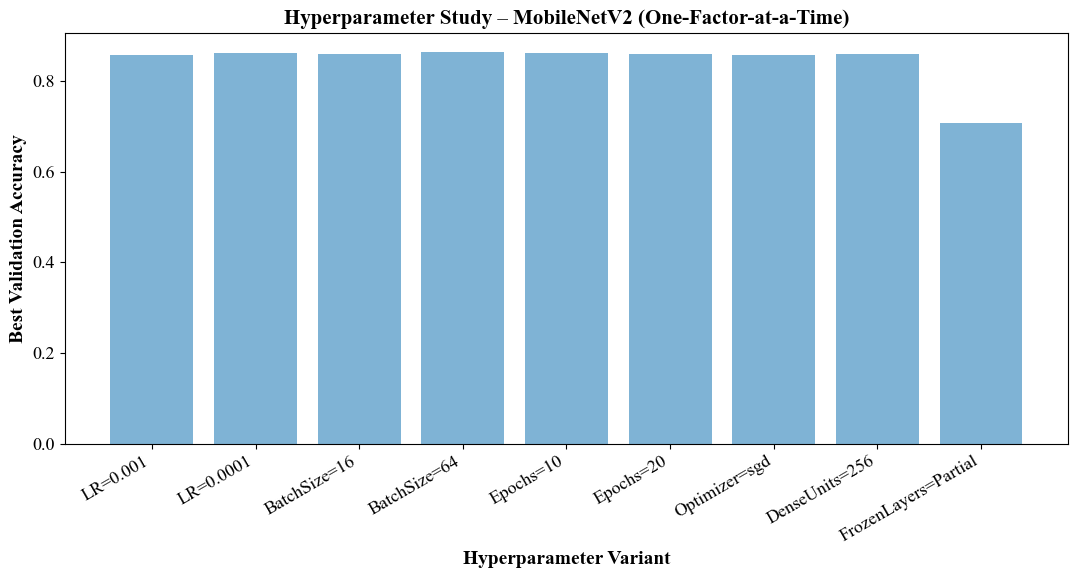

In [ ]:

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(hp_df['run'], hp_df['val_accuracy'], color='#7FB3D5')
ax.set_ylabel('Best Validation Accuracy', fontweight='bold')
ax.set_xlabel('Hyperparameter Variant', fontweight='bold')
ax.set_title('Hyperparameter Study – MobileNetV2 (One-Factor-at-a-Time)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_plot(fig, '09_hyperparameter_study.png')
plt.show()

hp_df.to_csv('/content/hyperparameter_study_results.csv', index=False)


## 12. Section 20, Item 1: VGG16 — Transfer Learning (Frozen Base, Single Run)

In [ ]:
vgg_model, vgg_base = build_transfer_model(
    applications.VGG16, applications.vgg16.preprocess_input,
    dense_units=128, trainable_base=False
)
vgg_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])
VGG_PARAMS = vgg_model.count_params()
print(f"VGG16 total parameters: {VGG_PARAMS:,}")

t0 = time.time()
vgg_history = vgg_model.fit(x_train, y_train, validation_data=(x_test, y_test),
                             epochs=10, batch_size=BATCH_SIZE, verbose=1)
vgg_time = time.time() - t0

vgg_eval = evaluate_model(vgg_model, x_test, y_test_int, CLASS_NAMES, "VGG16 (transfer learning)")
results['VGG16'] = {'params': VGG_PARAMS, 'accuracy': vgg_eval['accuracy'], 'train_time_sec': vgg_time}
histories['VGG16'] = vgg_history

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16 total parameters: 14,781,642
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 57ms/step - accuracy: 0.7669 - loss: 0.7569 - val_accuracy: 0.8063 - val_loss: 0.5645
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.8390 - loss: 0.4643 - val_accuracy: 0.8115 - val_loss: 0.5538
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.8609 - loss: 0.3950 - val_accuracy: 0.8155 - val_loss: 0.5542
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.8802 - loss: 0.3395 - val_accuracy: 0.8100 - val_loss: 0.5934
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.8982 - loss: 0.2899 - val_accuracy: 0.8087 - val_loss: 0.6407
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.9132 - loss: 0.2471 - val_accuracy: 0.7990 - val_loss: 0.6987
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.9238 - loss: 0.2177 - val_accuracy: 0.8068 - val_los

## 13. Section 20, Item 2: ResNet50 — Transfer Learning (Frozen Base, Single Run)

In [ ]:
resnet_model, resnet_base = build_transfer_model(
    applications.ResNet50, applications.resnet50.preprocess_input,
    dense_units=128, trainable_base=False
)
resnet_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                      loss='categorical_crossentropy', metrics=['accuracy'])
RESNET_PARAMS = resnet_model.count_params()
print(f"ResNet50 total parameters: {RESNET_PARAMS:,}")

t0 = time.time()
resnet_history = resnet_model.fit(x_train, y_train, validation_data=(x_test, y_test),
                                   epochs=10, batch_size=BATCH_SIZE, verbose=1)
resnet_time = time.time() - t0

resnet_eval = evaluate_model(resnet_model, x_test, y_test_int, CLASS_NAMES, "ResNet50 (transfer learning)")
results['ResNet50'] = {'params': RESNET_PARAMS, 'accuracy': resnet_eval['accuracy'], 'train_time_sec': resnet_time}
histories['ResNet50'] = resnet_history

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 total parameters: 23,851,274
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.8263 - loss: 0.5111 - val_accuracy: 0.8396 - val_loss: 0.4748
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.8759 - loss: 0.3562 - val_accuracy: 0.8516 - val_loss: 0.4479
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.8984 - loss: 0.2917 - val_accuracy: 0.8496 - val_loss: 0.4672
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9156 - loss: 0.2418 - val_accuracy: 0.8439 - val_loss: 0.5376
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.9286 - loss: 0.2028 - val_accuracy: 0.8436 - val_loss: 0.5886
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.9395 - loss: 0.1693 - val_accuracy: 0.8542 - val_loss: 0.5896
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.9488 - loss: 0.1453 - val_accuracy: 0.8508 - val_

## 13b. GoogleNet Row — InceptionV3 as a Labeled Stand-In

**No official pretrained GoogleNet / Inception-v1 weights exist** in Keras or any mainstream library, so literal GoogleNet transfer learning isn't something that can be run. **InceptionV3** (Google's real successor to GoogleNet, same Inception-module family) is used here as a labeled substitute.
Same treatment as VGG16/ResNet50: frozen-base transfer learning, single run, no fine-tuning.

In [ ]:
inception_model, inception_base = build_transfer_model(
    applications.InceptionV3, applications.inception_v3.preprocess_input,
    dense_units=128, trainable_base=False
)
inception_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                         loss='categorical_crossentropy', metrics=['accuracy'])
INCEPTION_PARAMS = inception_model.count_params()
print(f"InceptionV3 (GoogleNet stand-in) total parameters: {INCEPTION_PARAMS:,}")

t0 = time.time()
inception_history = inception_model.fit(x_train, y_train, validation_data=(x_test, y_test),
                                         epochs=10, batch_size=BATCH_SIZE, verbose=1)
inception_time = time.time() - t0

inception_eval = evaluate_model(inception_model, x_test, y_test_int, CLASS_NAMES,
                                 "InceptionV3 (GoogleNet stand-in, transfer learning)")
results['GoogleNet (via InceptionV3)'] = {
    'params': INCEPTION_PARAMS, 'accuracy': inception_eval['accuracy'], 'train_time_sec': inception_time
}
histories['GoogleNet_InceptionV3'] = inception_history

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
InceptionV3 (GoogleNet stand-in) total parameters: 22,066,346
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 29ms/step - accuracy: 0.6445 - loss: 1.0437 - val_accuracy: 0.6887 - val_loss: 0.9132
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7111 - loss: 0.8343 - val_accuracy: 0.6930 - val_loss: 0.8944
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.7412 - loss: 0.7465 - val_accuracy: 0.6916 - val_loss: 0.9132
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.7648 - loss: 0.6768 - val_accuracy: 0.6863 - val_loss: 0.9579
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.7869 - loss: 0.6131 - val_accuracy: 0.6831 - val_loss: 0.9967
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8049 - loss: 0.5571 - val_accuracy: 0.6777 - val_loss: 1.0552
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8267 - loss: 0.5012 - val

## 14. Section 20, Item 6 (part 1): LeNet-5 — Trained From Scratch

No pretrained ImageNet weights exist for LeNet-5, so this is a from-scratch training run on CIFAR-10, adapted to 3-channel 32×32 input.

In [ ]:
def build_lenet5():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(6, kernel_size=5, activation='tanh', padding='same'),
        layers.AveragePooling2D(pool_size=2),
        layers.Conv2D(16, kernel_size=5, activation='tanh'),
        layers.AveragePooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

lenet_model = build_lenet5()
lenet_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])
LENET_PARAMS = lenet_model.count_params()
print(f"LeNet-5 total parameters: {LENET_PARAMS:,}")

t0 = time.time()
lenet_history = lenet_model.fit(x_train, y_train, validation_data=(x_test, y_test),
                                 epochs=20, batch_size=BATCH_SIZE, verbose=1)
lenet_time = time.time() - t0

lenet_eval = evaluate_model(lenet_model, x_test, y_test_int, CLASS_NAMES, "LeNet-5 (from scratch)")
results['LeNet-5'] = {'params': LENET_PARAMS, 'accuracy': lenet_eval['accuracy'], 'train_time_sec': lenet_time}
histories['LeNet-5'] = lenet_history

LeNet-5 total parameters: 83,126
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3776 - loss: 1.7553 - val_accuracy: 0.4260 - val_loss: 1.6309
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4645 - loss: 1.5087 - val_accuracy: 0.4684 - val_loss: 1.4938
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5114 - loss: 1.3862 - val_accuracy: 0.4897 - val_loss: 1.4494
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5377 - loss: 1.3090 - val_accuracy: 0.5057 - val_loss: 1.3991
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5604 - loss: 1.2494 - val_accuracy: 0.5121 - val_loss: 1.3847
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5768 - loss: 1.2023 - val_accuracy: 0.5096 - val_loss: 1.3904
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5927 - loss: 1.1610 - val_accuracy: 0.5205 - val_loss: 1.3793
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step -

## 15. Section 20, Item 6 (part 2): AlexNet-Style — Trained From Scratch

The original AlexNet expects 227×227 input. For CIFAR-10 (32×32), this uses the standard **scaled-down AlexNet variant** conventional for small-image datasets — smaller strides/kernels than the original paper.

In [ ]:
def build_alexnet_cifar():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(64, kernel_size=3, strides=1, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(192, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'),
        layers.Conv2D(256, kernel_size=3, padding='same', activation='relu'),
        layers.Conv2D(256, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

alexnet_model = build_alexnet_cifar()
alexnet_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                       loss='categorical_crossentropy', metrics=['accuracy'])
ALEXNET_PARAMS = alexnet_model.count_params()
print(f"AlexNet-style total parameters: {ALEXNET_PARAMS:,}")

t0 = time.time()
alexnet_history = alexnet_model.fit(x_train, y_train, validation_data=(x_test, y_test),
                                     epochs=20, batch_size=BATCH_SIZE, verbose=1)
alexnet_time = time.time() - t0

alexnet_eval = evaluate_model(alexnet_model, x_test, y_test_int, CLASS_NAMES, "AlexNet-style (from scratch)")
results['AlexNet'] = {'params': ALEXNET_PARAMS, 'accuracy': alexnet_eval['accuracy'], 'train_time_sec': alexnet_time}
histories['AlexNet'] = alexnet_history

AlexNet-style total parameters: 6,976,842
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.3750 - loss: 1.6599 - val_accuracy: 0.5251 - val_loss: 1.2929
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5555 - loss: 1.2404 - val_accuracy: 0.6192 - val_loss: 1.0691
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6321 - loss: 1.0545 - val_accuracy: 0.6557 - val_loss: 0.9827
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6764 - loss: 0.9340 - val_accuracy: 0.6750 - val_loss: 0.9313
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7085 - loss: 0.8434 - val_accuracy: 0.6974 - val_loss: 0.8758
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7323 - loss: 0.7722 - val_accuracy: 0.6879 - val_loss: 0.9455
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7518 - loss: 0.7158 - val_accuracy: 0.7121 - val_loss: 0.8788
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━

## 16. Section 18.2: Final Comparative Table

The GoogleNet row uses **InceptionV3** results as a labeled stand-in (see Section 13b) — since no official pretrained GoogleNet/Inception-v1 weights exist anywhere, this is reported explicitly as a substitute, not as GoogleNet itself, to avoid misrepresenting what was run.

In [ ]:

comparison_rows = []
for model_name in ['LeNet-5', 'AlexNet', 'VGG16', 'ResNet50', 'MobileNetV2']:
    r = results[model_name]
    comparison_rows.append({
        'Model': model_name,
        'Parameters': f"{r['params']:,}",
        'Accuracy (%)': f"{r['accuracy']*100:.2f}",
        'Training Time (min)': f"{r['train_time_sec']/60:.2f}"
    })

r = results['GoogleNet (via InceptionV3)']
comparison_rows.append({
    'Model': 'GoogleNet*',
    'Parameters': f"{r['params']:,}",
    'Accuracy (%)': f"{r['accuracy']*100:.2f}",
    'Training Time (min)': f"{r['train_time_sec']/60:.2f}"
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv('/content/section_18_2_comparison_table.csv', index=False)
print("* GoogleNet row = InceptionV3 used as a labeled stand-in (no pretrained GoogleNet "
      "weights exist). Report this explicitly, not as literal GoogleNet.")
comparison_df


* GoogleNet row = InceptionV3 used as a labeled stand-in (no pretrained GoogleNet weights exist). Report this explicitly, not as literal GoogleNet.


,Model,Parameters,Accuracy (%),Training Time (min)
0,LeNet-5,"83,126",50.65,2.22
1,AlexNet,"6,976,842",71.52,6.53
2,VGG16,"14,781,642",79.96,14.21
3,ResNet50,"23,851,274",84.81,6.82
4,MobileNetV2,"2,423,242",85.10,7.63
5,GoogleNet*,"22,066,346",65.78,5.24


## 17. Save Everything: Plots (ZIP), Comparison Table, Hyperparameter Results

Zips the `plots/` folder and downloads it immediately

In [ ]:

zip_path = '/content/experiment4_plots.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir(PLOTS_DIR)):
        zf.write(os.path.join(PLOTS_DIR, fname), arcname=fname)

print("Plots included in ZIP:")
for fname in sorted(os.listdir(PLOTS_DIR)):
    print(" -", fname)

files.download(zip_path)
files.download('/content/section_18_2_comparison_table.csv')
files.download('/content/hyperparameter_study_results.csv')


Plots included in ZIP:
 - 01_sample_images.png
 - 02_training_accuracy.png
 - 03_validation_accuracy.png
 - 04_training_loss.png
 - 05_validation_loss.png
 - 06_before_after_finetuning.png
 - 07_confusion_matrix.png
 - 08_misclassified_images.png
 - 09_hyperparameter_study.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>